# Havfisken length-distribution analysis

This notebook compares fish length distributions across the 2024, 2025, and 2026 (Day 1 & Day 3) Øresund surveys.

**Species covered:** European plaice, dab, sprat, cod, whiting, herring, and European flounder — whichever species were recorded in each survey.

## 1. Setup

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

## 2. Helper functions

- `expand_to_individual_fish` turns a (length bin, count) table into a flat array of individual lengths.
- `load_species` reads one `LENGTH GROUP (cm)` / count column pair from a sheet and returns those individual lengths.

In [34]:
def expand_to_individual_fish(length_group, count):
    """
    Convert a (length bin, count) frequency table into a 1D array of
    individual fish lengths, e.g. length=18, count=7 -> seven 18.0 entries.
    """
    df = pd.DataFrame({'length': length_group, 'count': count}).dropna()
    df = df[df['count'] > 0]
    return np.repeat(df['length'].values, df['count'].astype(int).values)


def load_species(path, sheet, header, length_col, count_col):
    """Read one species' LENGTH GROUP / count column pair from a sheet
    and return individual fish lengths."""
    data = pd.read_excel(path, sheet_name=sheet, header=header)
    return expand_to_individual_fish(data[length_col], data[count_col])

## 3. Load all species from every survey occasion

Column pairs were identified directly from each sheet's header labels (e.g. *"LENGTH DISTRIBUTION SPRAT (brisling) 2026"*), so each species is read from the correct block of columns.

In [35]:
# --- 2024: plaice, sprat, cod ---
f2024 = 'Oceanography_catch_Havfisken_2024.xlsx'
sheet2024 = 'Length distribution'

plaice_2024 = load_species(f2024, sheet2024, 6, 'LENGTH GROUP (cm)', 'NR')
herring_sprat_2024  = load_species(f2024, sheet2024, 6, 'LENGTH GROUP (cm).1', 'NR.1')
cod_2024    = load_species(f2024, sheet2024, 6, 'LENGTH GROUP (cm).2', 'NR.2')

In [36]:
# --- 2025: plaice, dab ---
f2025 = 'Oceanography_catch_Havfisken_2025.xlsx'
sheet2025 = 'Length distribution'

plaice_2025 = load_species(f2025, sheet2025, 2, 'LENGTH GROUP (cm)', 'Abundance (# fish)')
dab_2025    = load_species(f2025, sheet2025, 2, 'LENGTH GROUP (cm).1', 'Abundance (# fish).1')

In [37]:
# --- 2026 Day 1: plaice, sprat, whiting, dab ---
f2026 = 'Oceanography_catch_Havfisken_2026.xlsx'
sheet2026_d1 = 'Length distribution day1'

plaice_2026_d1  = load_species(f2026, sheet2026_d1, 6, 'LENGTH GROUP (cm)', 'NR')
sprat_2026_d1   = load_species(f2026, sheet2026_d1, 6, 'LENGTH GROUP (cm).1', 'NR.1')
whiting_2026_d1 = load_species(f2026, sheet2026_d1, 6, 'LENGTH GROUP (cm).2', 'NR.2')
dab_2026_d1     = load_species(f2026, sheet2026_d1, 6, 'LENGTH GROUP (cm).3', 'NR.3')

In [38]:
# --- 2026 Day 3: plaice, sprat, whiting, herring, flounder, dab ---
sheet2026_d3 = 'Length distribution day3'

plaice_2026_d3   = load_species(f2026, sheet2026_d3, 6, 'LENGTH GROUP (cm)', 'NR')
sprat_2026_d3    = load_species(f2026, sheet2026_d3, 6, 'LENGTH GROUP (cm).1', 'NR.1') 
whiting_2026_d3  = load_species(f2026, sheet2026_d3, 6, 'LENGTH GROUP (cm).2', 'NR.2')
herring_2026_d3 = load_species(f2026, sheet2026_d3, 6, 'LENGTH GROUP (cm).3', 'NR.3')
flounder_2026_d3 = load_species(f2026, sheet2026_d3, 6, 'LENGTH GROUP (cm).4', 'NR.4')
dab_2026_d3      = load_species(f2026, sheet2026_d3, 6, 'LENGTH GROUP (cm).5', 'NR.5')



### 3a. Combine herring and sprat (2026)

Herring and sprat are visually similar and were pooled for the 2026 survey, so their length measurements are combined into a single `Herring + Sprat` group for Day 1 and Day 3. (No herring were recorded on Day 1, so that occasion is just the sprat lengths.)

In [39]:
# --- 2026: combine herring + sprat length measurements ---
herring_sprat_2026_d1 = sprat_2026_d1  # no herring caught on Day 1
herring_sprat_2026_d3 = np.concatenate([herring_2026_d3, sprat_2026_d3])


## 4. Organize by species

Group every occasion's data under its species name, so each species can be plotted across all the years/days it was recorded in.

In [40]:
# species -> {occasion_label: array_of_lengths}
# NOTE: herring and sprat are pooled into a single 'Herring + Sprat' group
# for the 2026 occasions (see step 3a above), since they were not separated
# in that survey.
species_data = {
    'European Plaice': {
        '02/06/2023': plaice_2024,
        '10/06/2025': plaice_2025,
        '09/06/2026': plaice_2026_d1,
        '11/06/2026': plaice_2026_d3,
    },
    'Dab': {
        '10/06/2025': dab_2025,
        '09/06/2026': dab_2026_d1,
        '11/06/2026': dab_2026_d3,  
    },
    'Whiting': {
        '09/06/2026': whiting_2026_d1,
        '11/06/2026': whiting_2026_d3,
    },
    'Cod': {
        '02/06/2023': cod_2024,
    },
    'Herring + Sprat': {
        '02/06/2023': herring_sprat_2024,
        '09/06/2026': herring_sprat_2026_d1,
        '11/06/2026': herring_sprat_2026_d3,
    },
    'European flounder': {
        '11/06/2026': flounder_2026_d3,
    },
}

# Drop any species/occasion combos with zero fish caught
species_data = {
    sp: {occ: vals for occ, vals in occs.items() if len(vals) > 0}
    for sp, occs in species_data.items()
}
species_data = {sp: occs for sp, occs in species_data.items() if occs}

for sp, occs in species_data.items():
    counts = {occ: len(v) for occ, v in occs.items()}
    print(f'{sp}: {counts}')


European Plaice: {'02/06/2023': 109, '10/06/2025': 73, '09/06/2026': 50, '11/06/2026': 50}
Dab: {'10/06/2025': 171, '09/06/2026': 52, '11/06/2026': 50}
Whiting: {'09/06/2026': 42, '11/06/2026': 33}
Cod: {'02/06/2023': 151}
Herring + Sprat: {'02/06/2023': 245, '09/06/2026': 31, '11/06/2026': 120}
European flounder: {'11/06/2026': 51}


## 5. Boxplot: every species separately

One figure per species, with a separate box for each survey occasion it appeared in. Each species is saved as its own PNG.

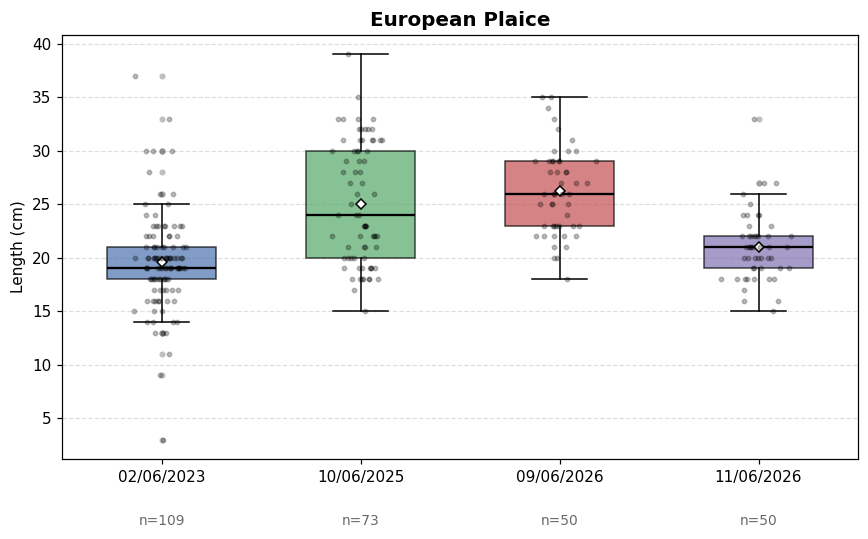

Saved: boxplot_european_plaice.png


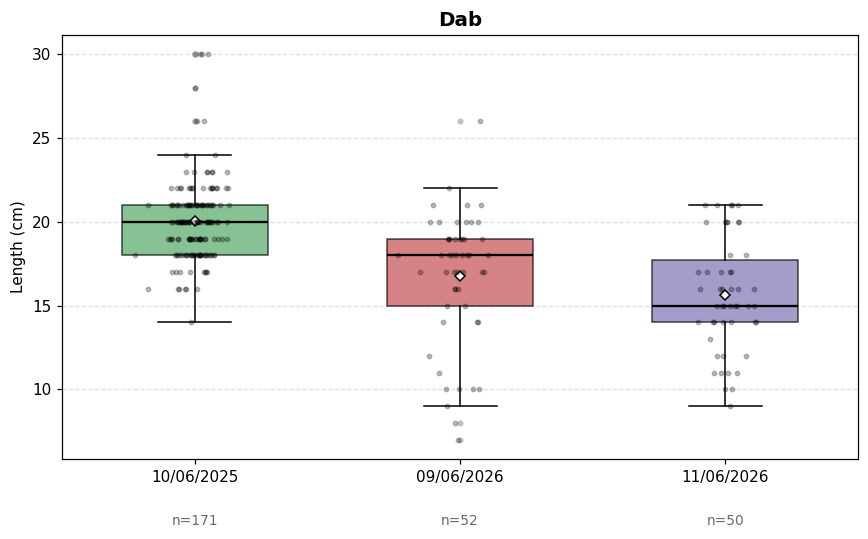

Saved: boxplot_dab.png


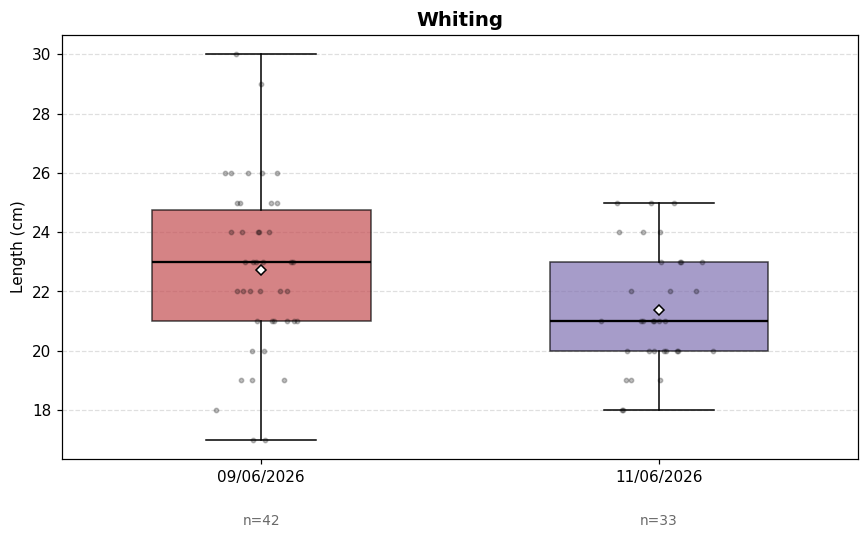

Saved: boxplot_whiting.png


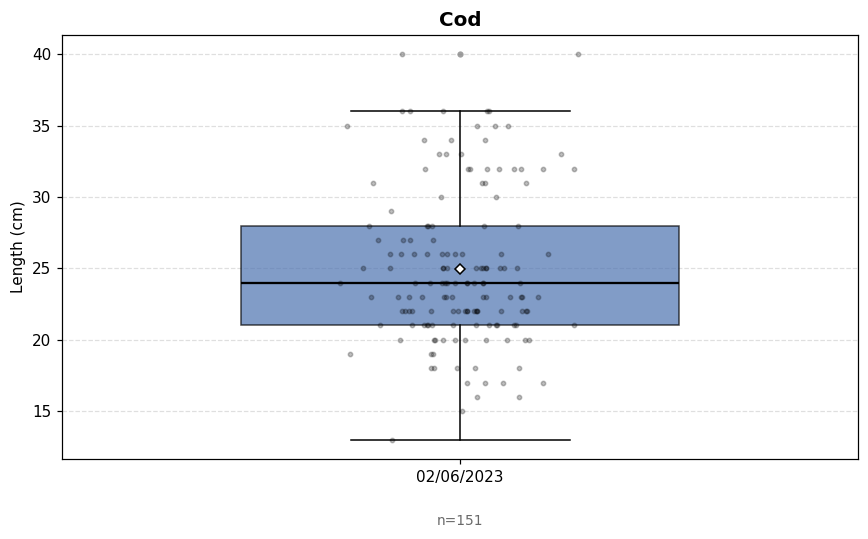

Saved: boxplot_cod.png


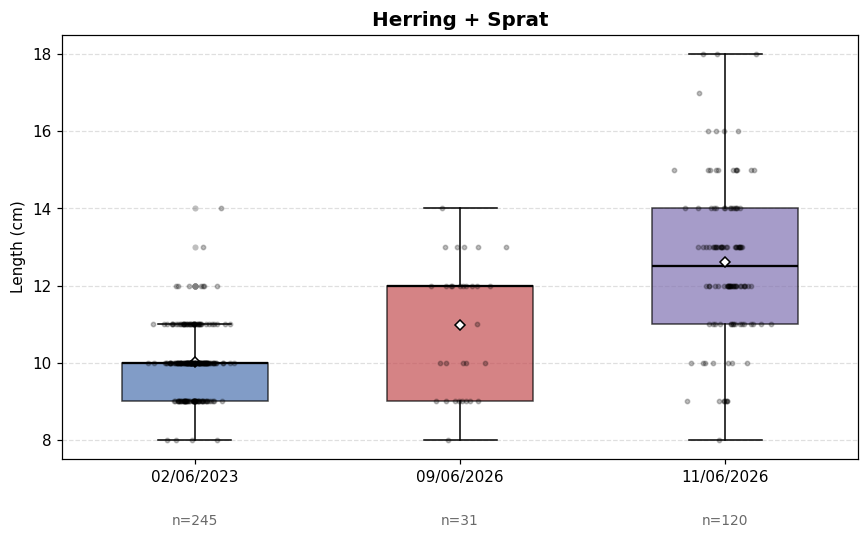

Saved: boxplot_herring_+_sprat.png


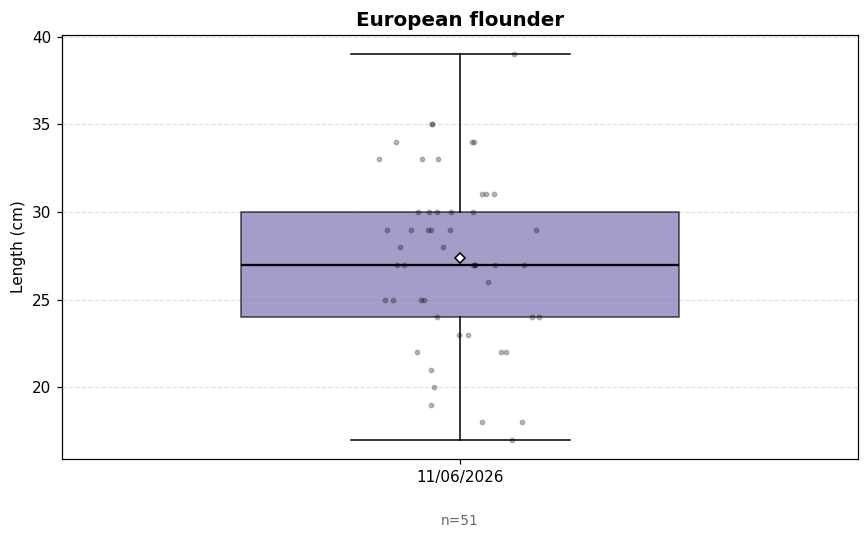

Saved: boxplot_european_flounder.png


In [41]:
occasion_colors = {
    '02/06/2023': '#4C72B0',
    '10/06/2025': '#55A868',
    '09/06/2026': '#C44E52',
    '11/06/2026': '#8172B2',
}

rng = np.random.default_rng(0)

FIGSIZE = (8, 5)  # fixed size for every figure

for species, occs in species_data.items():
    labels = list(occs.keys())
    values = list(occs.values())

    fig, ax = plt.subplots(figsize=FIGSIZE)

    box = ax.boxplot(
        values,
        tick_labels=labels,
        patch_artist=True,
        widths=0.55,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='white',
                       markeredgecolor='black', markersize=5),
        medianprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='grey',
                        markeredgecolor='none', alpha=0.5, markersize=4),
    )

    for patch, label in zip(box['boxes'], labels):
        patch.set_facecolor(occasion_colors.get(label, '#999999'))
        patch.set_alpha(0.7)

    for i, v in enumerate(values, start=1):
        jitter = rng.normal(0, 0.06, size=len(v))
        ax.scatter(np.full(len(v), i) + jitter, v,
                   color='black', alpha=0.25, s=8, zorder=3)

    for i, v in enumerate(values, start=1):
        ax.text(i, -0.13, f'n={len(v)}',
                ha='center', va='top', fontsize=9, color='dimgrey',
                transform=ax.get_xaxis_transform())

    ax.set_title(species, fontweight='bold', fontsize=13)
    ax.set_ylabel('Length (cm)')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    fig.tight_layout()
    fname = f"boxplot_{species.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

## 6. Length-frequency histograms, per species

One figure per species overlaying all survey occasions for that species.

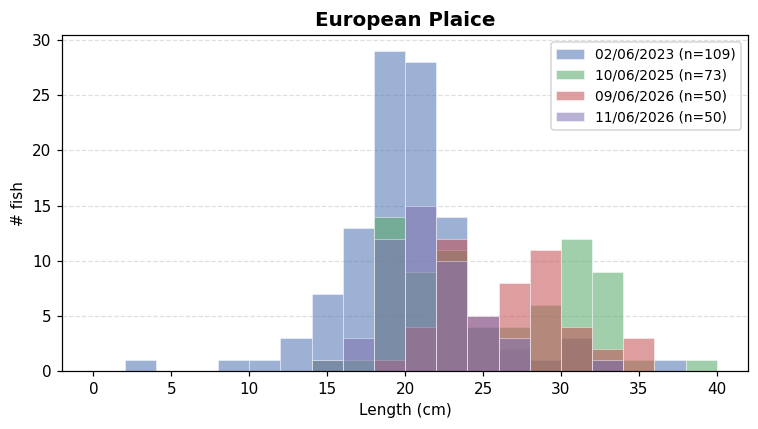

Saved: histogram_european_plaice.png


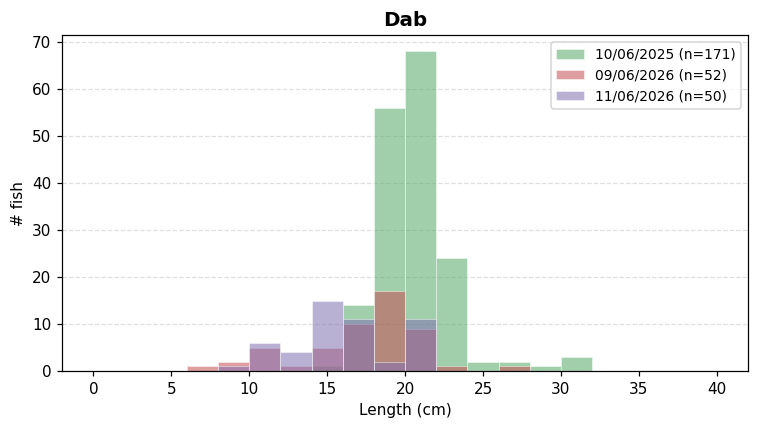

Saved: histogram_dab.png


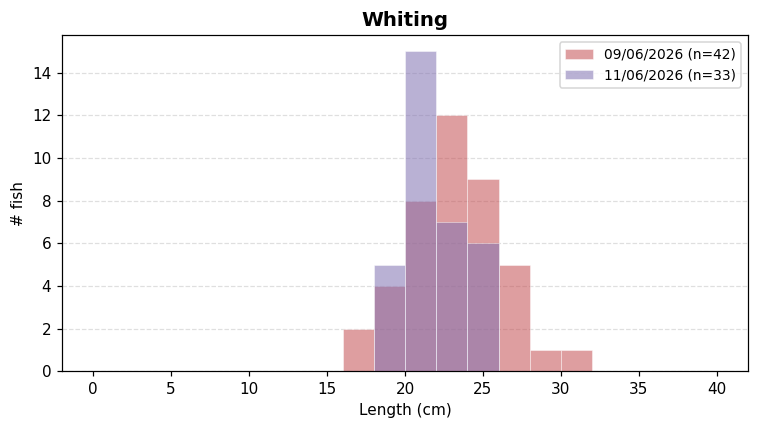

Saved: histogram_whiting.png


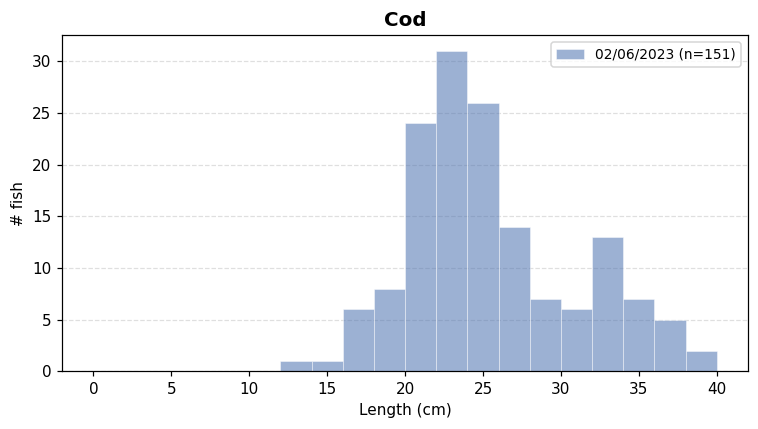

Saved: histogram_cod.png


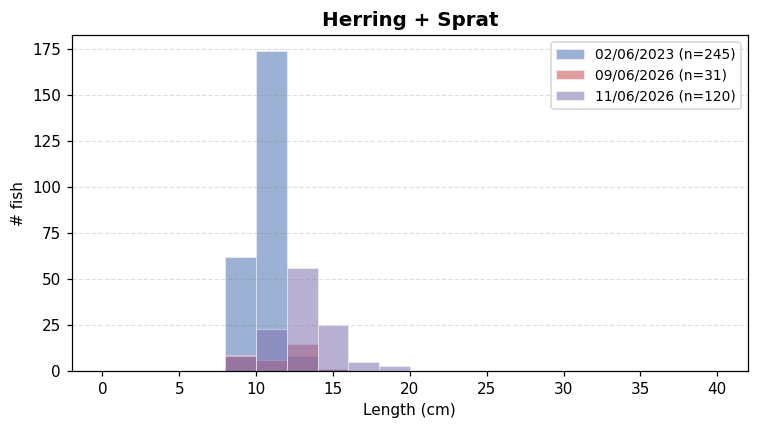

Saved: histogram_herring_+_sprat.png


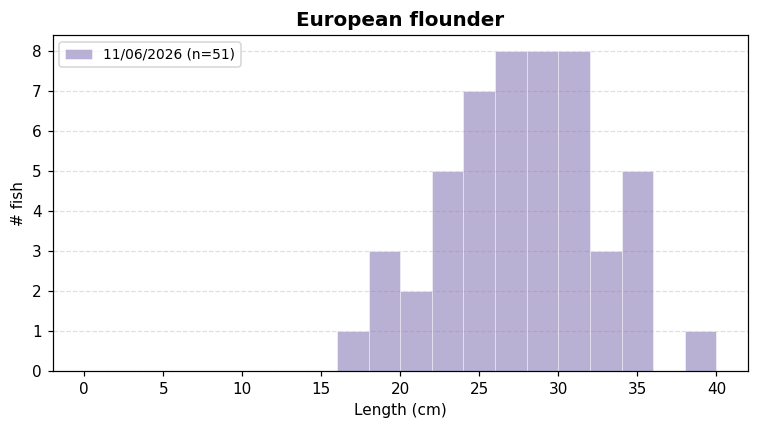

Saved: histogram_european_flounder.png


In [42]:
bins = np.arange(0, 42, 2)  # 2 cm bins

for species, occs in species_data.items():
    fig, ax = plt.subplots(figsize=(7, 4))

    for label, vals in occs.items():
        clean_label = label.replace('\n', ' ')
        ax.hist(vals, bins=bins, alpha=0.55,
                label=f"{clean_label} (n={len(vals)})",
                color=occasion_colors.get(label, '#999999'),
                edgecolor='white', linewidth=0.5)

    ax.set_title(species, fontweight='bold', fontsize=13)
    ax.set_xlabel('Length (cm)')
    ax.set_ylabel('# fish')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    fig.tight_layout()
    fname = f"histogram_{species.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


## 7. 2026 catch weights

Total catch weight per survey day and species breakdown.

Weight data is read from the **Day1** and **Day3** sheets of the 2026 workbook, which list each species' subsample weight (kg) alongside the total catch (kg) and raising factor.

In [43]:
import pandas as pd

def read_catch_sheet(path, sheet):
    """
    Parse a catch-statistics sheet from the 2026 workbook.
    Returns (total_kg, subsample_kg, raising_factor, species_df)
    where species_df has columns: species, subsample_weight_kg, cpue_kg_per_15min
    """
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    total_kg      = float(raw.iloc[4, 1])
    subsample_kg  = float(raw.iloc[5, 1])
    raising_factor = float(raw.iloc[6, 1])

    # Species table starts at row 8 (0-indexed), columns 0-3
    tbl = raw.iloc[8:, [0, 1, 3]].copy()
    tbl.columns = ['species', 'subsample_weight_kg', 'cpue_kg_per_15min']
    tbl = tbl.dropna(subset=['species'])
    tbl = tbl[tbl['species'].str.strip().str.upper() != 'TOTAAL']
    tbl = tbl[tbl['subsample_weight_kg'].notna()]
    tbl['species'] = tbl['species'].str.strip().str.title()
    tbl['subsample_weight_kg'] = pd.to_numeric(tbl['subsample_weight_kg'], errors='coerce')
    tbl['cpue_kg_per_15min']   = pd.to_numeric(tbl['cpue_kg_per_15min'],   errors='coerce')
    tbl = tbl.dropna(subset=['subsample_weight_kg'])
    return total_kg, subsample_kg, raising_factor, tbl.reset_index(drop=True)

f2026 = 'Oceanography_catch_Havfisken_2026.xlsx'

total_d1, subsample_d1, rf_d1, species_d1 = read_catch_sheet(f2026, 'Day1')
total_d3, subsample_d3, rf_d3, species_d3 = read_catch_sheet(f2026, 'Day3')

print(f"Day 1 — Total: {total_d1} kg | Subsample: {subsample_d1} kg | RF: {rf_d1:.4f}")
print(species_d1.to_string(index=False))
print()
print(f"Day 3 — Total: {total_d3} kg | Subsample: {subsample_d3} kg | RF: {rf_d3:.4f}")
print(species_d3.to_string(index=False))


Day 1 — Total: 197.0 kg | Subsample: 38.62 kg | RF: 5.1010
      species  subsample_weight_kg  cpue_kg_per_15min
          Dab                37.70         192.307095
       Plaice               116.00         591.714138
      Whiting                 3.80          19.383739
Sprat/Herring                20.00         102.019679
     Flounder                 2.20          11.222165
      Gurnard                 4.00          20.403936
         Sole                 0.50                NaN
          Cod                 0.10                NaN
     Dragonet                 0.01                NaN

Day 3 — Total: 187.0 kg | Subsample: 38.62 kg | RF: 4.8421
      species  subsample_weight_kg  cpue_kg_per_15min
       Plaice               117.00         566.519938
          Dab                41.00         198.524081
     Flounder                18.35          88.851631
Sprat/Herring                 2.00           9.684102
      Whiting                 2.50          12.105127
          Cod    

### 7a-pre. Combine herring + sprat catch weights (2026)

Same pooling as the length-distribution data above: herring and sprat weights are summed into a single `Herring + Sprat` row for each day, since the two species were not weighed separately in the 2026 survey.

In [44]:
def merge_species_rows(df, keywords, new_name):
    """Sum rows whose species name contains any of `keywords` (case-insensitive) into one row called `new_name`."""
    mask = df['species'].str.lower().apply(lambda s: any(k in s for k in keywords))
    if mask.sum() == 0:
        return df
    merged_row = pd.DataFrame({
        'species': [new_name],
        'subsample_weight_kg': [df.loc[mask, 'subsample_weight_kg'].sum()],
        'cpue_kg_per_15min': [df.loc[mask, 'cpue_kg_per_15min'].sum()],
    })
    rest = df.loc[~mask].reset_index(drop=True)
    return pd.concat([rest, merged_row], ignore_index=True)

species_d1 = merge_species_rows(species_d1, ['sprat', 'herring'], 'Herring + Sprat')
species_d3 = merge_species_rows(species_d3, ['sprat', 'herring'], 'Herring + Sprat')

print('Day 1 (merged):')
print(species_d1.to_string(index=False))
print()
print('Day 3 (merged):')
print(species_d3.to_string(index=False))


Day 1 (merged):
        species  subsample_weight_kg  cpue_kg_per_15min
            Dab                37.70         192.307095
         Plaice               116.00         591.714138
        Whiting                 3.80          19.383739
       Flounder                 2.20          11.222165
        Gurnard                 4.00          20.403936
           Sole                 0.50                NaN
            Cod                 0.10                NaN
       Dragonet                 0.01                NaN
Herring + Sprat                20.00         102.019679

Day 3 (merged):
        species  subsample_weight_kg  cpue_kg_per_15min
         Plaice               117.00         566.519938
            Dab                41.00         198.524081
       Flounder                18.35          88.851631
        Whiting                 2.50          12.105127
            Cod                 0.70           3.389436
           Sole                 1.50                NaN
        Gurnard

### 7d. Species weight composition (pie charts)

Proportion of total subsample weight contributed by each species, per survey day.

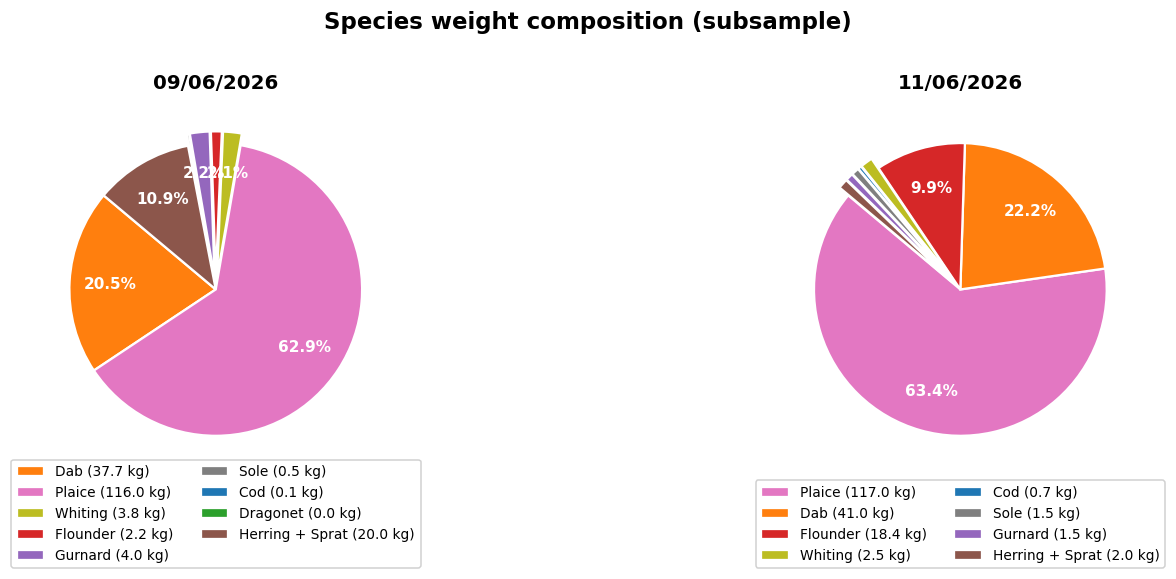

In [45]:
# Distinct qualitative palette — enough colors for up to 10 species
PALETTE = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
]

# Build a shared species -> color mapping across both days
all_species = pd.concat([species_d1, species_d3])['species'].unique()
species_color = {sp: PALETTE[i % len(PALETTE)] for i, sp in enumerate(sorted(all_species))}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, day in zip(
    axes,
    [species_d1, species_d3],
    ['09/06/2026', '11/06/2026'],
):
    labels = df['species'].values
    sizes  = df['subsample_weight_kg'].values
    colors = [species_color[sp] for sp in labels]

    # Explode tiny slices (<3%) so they're easier to see
    explode = [0.08 if s / sizes.sum() < 0.03 else 0 for s in sizes]

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=None,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        explode=explode,
        pctdistance=0.72,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
    )

    for autotext, size in zip(autotexts, sizes):
        pct = size / sizes.sum() * 100
        if pct < 2:
            autotext.set_visible(False)
        else:
            autotext.set_fontsize(10)
            autotext.set_fontweight('bold')
            autotext.set_color('white')

    ax.legend(
        wedges, [f'{l} ({s:.1f} kg)' for l, s in zip(labels, sizes)],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.28),
        ncol=2,
        fontsize=9,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
    )

    ax.set_title(f'{day}', fontweight='bold', fontsize=13, pad=12)

fig.suptitle('Species weight composition (subsample)', fontweight='bold', fontsize=15)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig('2026_species_weight_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary table

Quick numeric summary (count, mean, median, min/max length) for every species/occasion combination.

In [46]:
summary_rows = []
for species, occs in species_data.items():
    for occasion, vals in occs.items():
        summary_rows.append({
            'Species': species,
            'Occasion': occasion.replace('\n', ' '),
            'n': len(vals),
            'Mean (cm)': round(vals.mean(), 1),
            'Median (cm)': float(np.median(vals)),
            'Std dev (cm)': round(vals.std(ddof=1), 1) if len(vals) > 1 else float('nan'),
            'Min (cm)': float(vals.min()),
            'Max (cm)': float(vals.max()),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Species,Occasion,n,Mean (cm),Median (cm),Std dev (cm),Min (cm),Max (cm)
0,European Plaice,02/06/2023,109,19.6,19.0,4.5,3.0,37.0
1,European Plaice,10/06/2025,73,25.1,24.0,5.6,15.0,39.0
2,European Plaice,09/06/2026,50,26.2,26.0,4.0,18.0,35.0
3,European Plaice,11/06/2026,50,21.0,21.0,3.2,15.0,33.0
4,Dab,10/06/2025,171,20.0,20.0,2.4,14.0,30.0
5,Dab,09/06/2026,52,16.8,18.0,3.9,7.0,26.0
6,Dab,11/06/2026,50,15.6,15.0,3.3,9.0,21.0
7,Whiting,09/06/2026,42,22.7,23.0,2.9,17.0,30.0
8,Whiting,11/06/2026,33,21.4,21.0,2.0,18.0,25.0
9,Cod,02/06/2023,151,25.0,24.0,5.4,13.0,40.0


### 8a. Report-friendly summary text

Plain-text lines (mean ± SD, n, median) ready to copy straight into the report.

In [47]:
for _, row in summary_df.iterrows():
    print(
        f"{row['Species']} ({row['Occasion']}): "
        f"mean = {row['Mean (cm)']:.1f} cm, "
        f"SD = {row['Std dev (cm)']:.1f} cm, "
        f"median = {row['Median (cm)']:.1f} cm, "
        f"n = {row['n']} "
        f"(range {row['Min (cm)']:.1f}\u2013{row['Max (cm)']:.1f} cm)"
    )


European Plaice (02/06/2023): mean = 19.6 cm, SD = 4.5 cm, median = 19.0 cm, n = 109 (range 3.0–37.0 cm)
European Plaice (10/06/2025): mean = 25.1 cm, SD = 5.6 cm, median = 24.0 cm, n = 73 (range 15.0–39.0 cm)
European Plaice (09/06/2026): mean = 26.2 cm, SD = 4.0 cm, median = 26.0 cm, n = 50 (range 18.0–35.0 cm)
European Plaice (11/06/2026): mean = 21.0 cm, SD = 3.2 cm, median = 21.0 cm, n = 50 (range 15.0–33.0 cm)
Dab (10/06/2025): mean = 20.0 cm, SD = 2.4 cm, median = 20.0 cm, n = 171 (range 14.0–30.0 cm)
Dab (09/06/2026): mean = 16.8 cm, SD = 3.9 cm, median = 18.0 cm, n = 52 (range 7.0–26.0 cm)
Dab (11/06/2026): mean = 15.6 cm, SD = 3.3 cm, median = 15.0 cm, n = 50 (range 9.0–21.0 cm)
Whiting (09/06/2026): mean = 22.7 cm, SD = 2.9 cm, median = 23.0 cm, n = 42 (range 17.0–30.0 cm)
Whiting (11/06/2026): mean = 21.4 cm, SD = 2.0 cm, median = 21.0 cm, n = 33 (range 18.0–25.0 cm)
Cod (02/06/2023): mean = 25.0 cm, SD = 5.4 cm, median = 24.0 cm, n = 151 (range 13.0–40.0 cm)
Herring + Spra